# LC Resonant Converter — Complementary MOSFET Gate Waveforms
| | |
|---|---|
| **CH1** | High-side FET gate (`FET_CH1.csv`) |
| **CH2** | Low-side FET gate (`FET_CH2.csv`) |
| **Start** | −70 µs |
| **Sample rate** | 1 GS/s (1 ns) |
| **Samples** | ~140 000 per channel |

## 1. Imports & style

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from scipy import signal

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

C1 = '#185FA5'   # CH1 colour  (blue)
C2 = '#0F6E56'   # CH2 colour  (teal)

## 2. Load both channels

In [2]:
START_S = -7e-5
INC_S   =  1e-9

def load_channel(path):
    seqs, volts = [], []
    with open(path, newline='') as f:
        for row in csv.reader(f):
            if len(row) < 2:
                continue
            try:
                seqs.append(int(row[0]))
                volts.append(float(row[1]))
            except ValueError:
                pass
    seq   = np.array(seqs)
    volts = np.array(volts)
    time  = (START_S + seq * INC_S) * 1e6   # µs
    return time, volts

t1, v1 = load_channel('FET_CH1.csv')
t2, v2 = load_channel('FET_CH2.csv')

assert np.allclose(t1, t2, atol=1e-6), 'Timestamps mismatch between channels!'
time_us = t1   # shared axis

for ch, v in [('CH1 (high-side)', v1), ('CH2 (low-side)', v2)]:
    print(f"{ch:20s}  n={len(v):,}  min={v.min():.3f} V  max={v.max():.3f} V  mean={v.mean():.3f} V  std={v.std():.4f} V")

CH1 (high-side)       n=140,000  min=-0.800 V  max=12.800 V  mean=5.483 V  std=5.9690 V
CH2 (low-side)        n=140,000  min=-1.200 V  max=15.600 V  mean=6.767 V  std=4.7260 V


## 3. Full overview — both channels overlaid

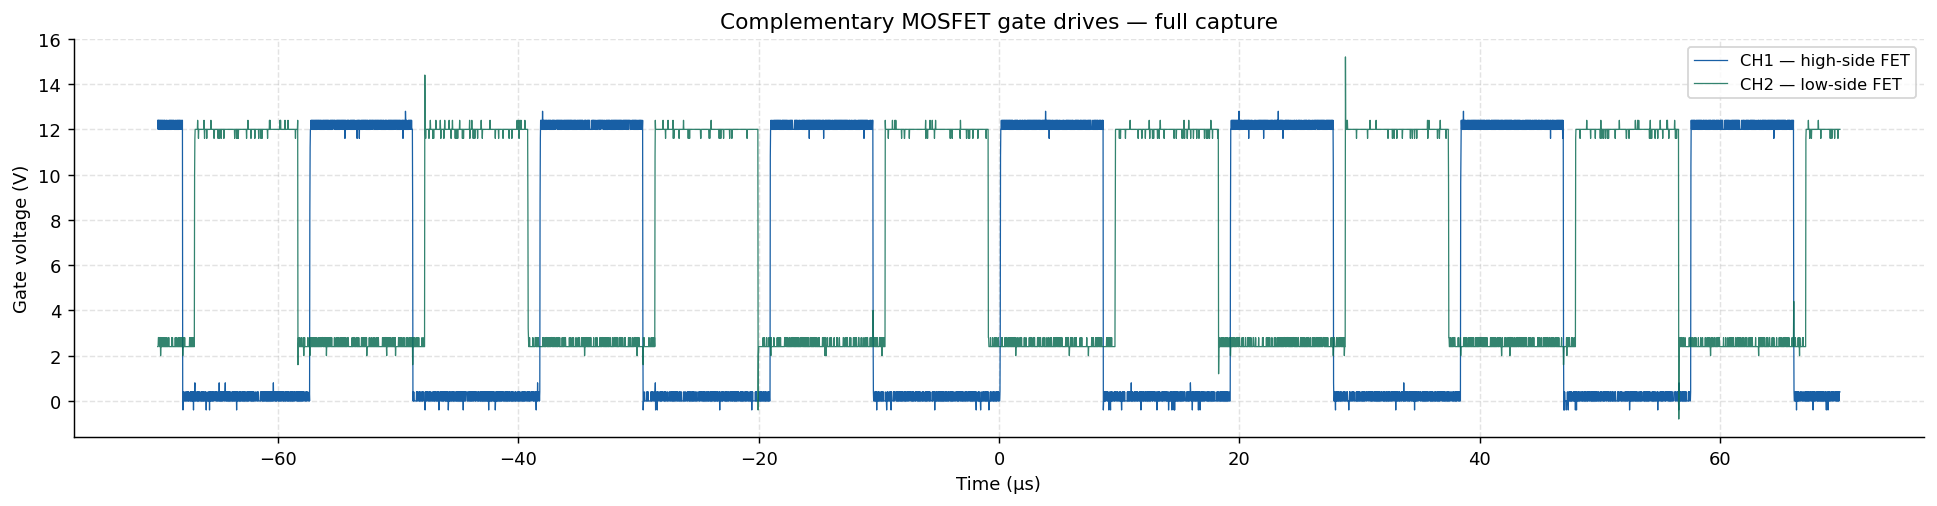

In [3]:
N = max(1, len(time_us) // 6000)   # downsample for speed
tp = time_us[::N]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(tp, v1[::N], lw=0.7, color=C1, label='CH1 — high-side FET', rasterized=True)
ax.plot(tp, v2[::N], lw=0.7, color=C2, label='CH2 — low-side FET',  rasterized=True, alpha=0.85)
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Gate voltage (V)')
ax.set_title('Complementary MOSFET gate drives — full capture')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Stacked subplots — easier to compare levels

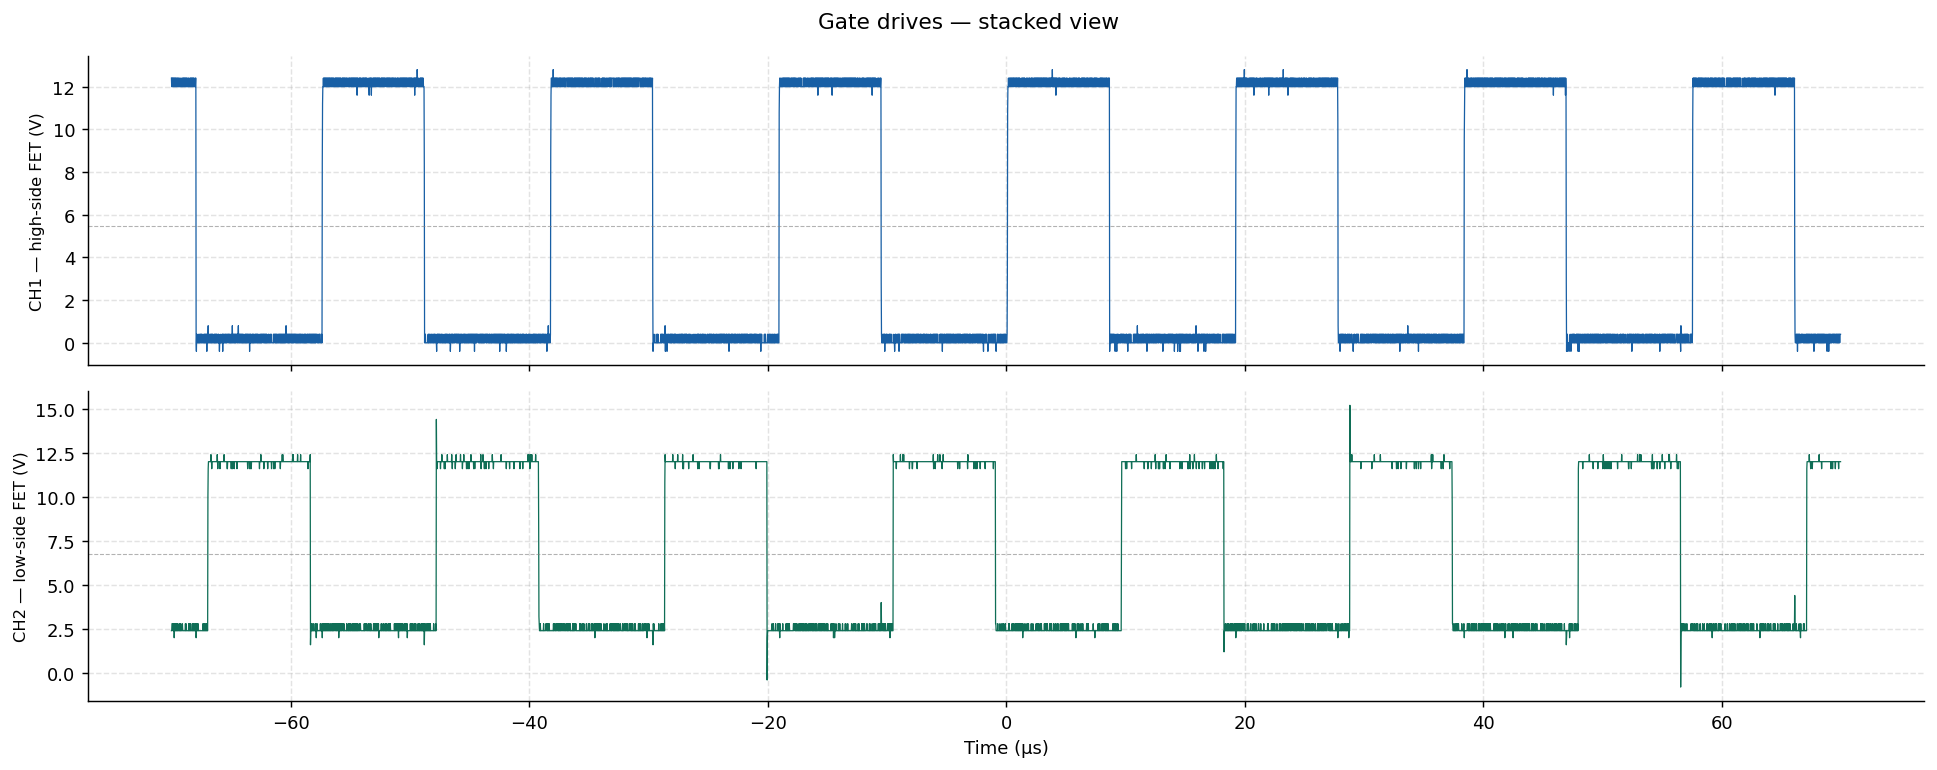

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
fig.suptitle('Gate drives — stacked view', fontsize=12)

for ax, v, color, label in [
    (axes[0], v1, C1, 'CH1 — high-side FET (V)'),
    (axes[1], v2, C2, 'CH2 — low-side FET (V)'),
]:
    ax.plot(tp, v[::N], lw=0.7, color=color, rasterized=True)
    ax.set_ylabel(label, fontsize=9)
    ax.axhline(v.mean(), color='gray', lw=0.6, ls='--', alpha=0.6)

axes[1].set_xlabel('Time (µs)')
plt.tight_layout()
plt.show()

## 5. Zoom window — inspect dead-time & switching
Edit `T_START` / `T_END` (µs) to focus on any region.

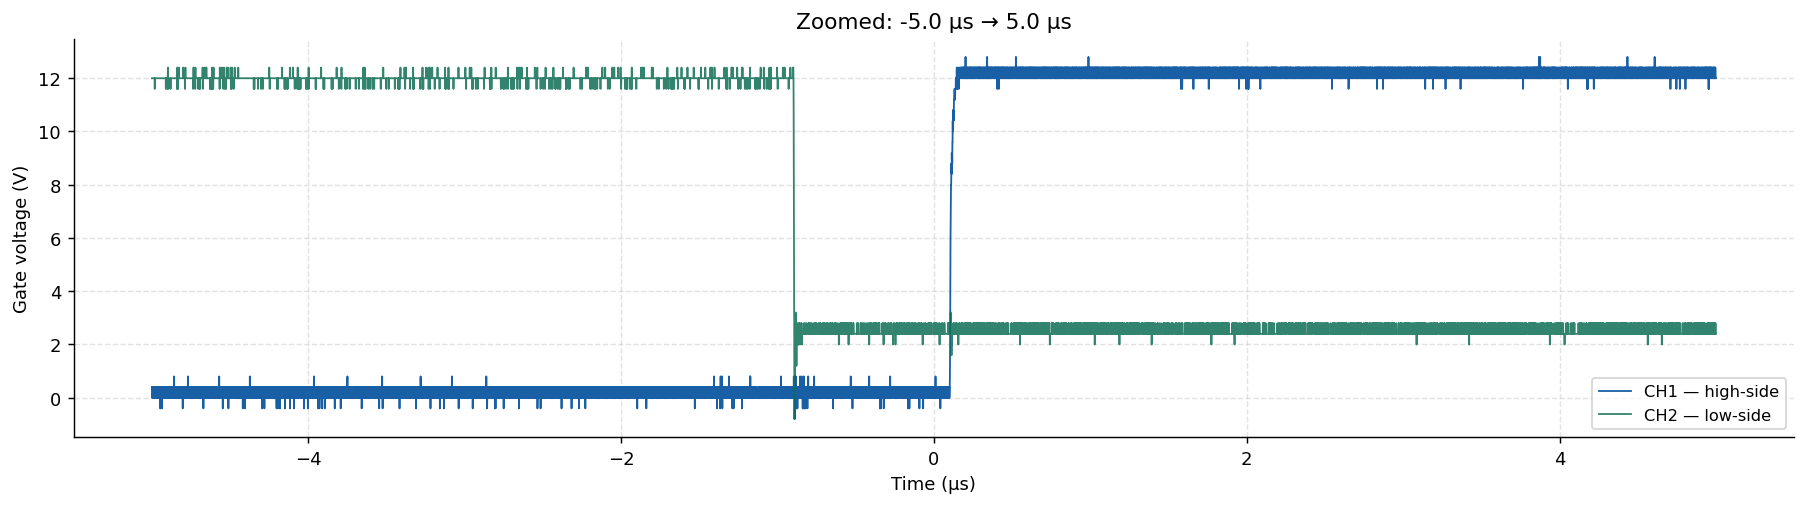

Points in window: 10,000


In [5]:
T_START = -5.0   # µs
T_END   =  5.0   # µs

mask = (time_us >= T_START) & (time_us <= T_END)
tw   = time_us[mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(tw, v1[mask], lw=1.0, color=C1, label='CH1 — high-side')
ax.plot(tw, v2[mask], lw=1.0, color=C2, label='CH2 — low-side', alpha=0.85)
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Gate voltage (V)')
ax.set_title(f'Zoomed: {T_START} µs → {T_END} µs')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Points in window: {mask.sum():,}')

## 6. Dead-time / overlap analysis
Both FETs conducting simultaneously is shoot-through — dangerous!  
This cell finds periods where both gates are above their respective thresholds.

Thresholds  — CH1: 6.000 V   CH2: 7.200 V
Total capture      : 140.0 µs
CH1 on only        : 61.99 µs  (44.3%)
CH2 on only        : 62.97 µs  (45.0%)
Both off (dead-time): 15039.0 ns  (10.74%)
SHOOT-THROUGH       : 0.0 ns  (0.0000%)  <-- should be ~0


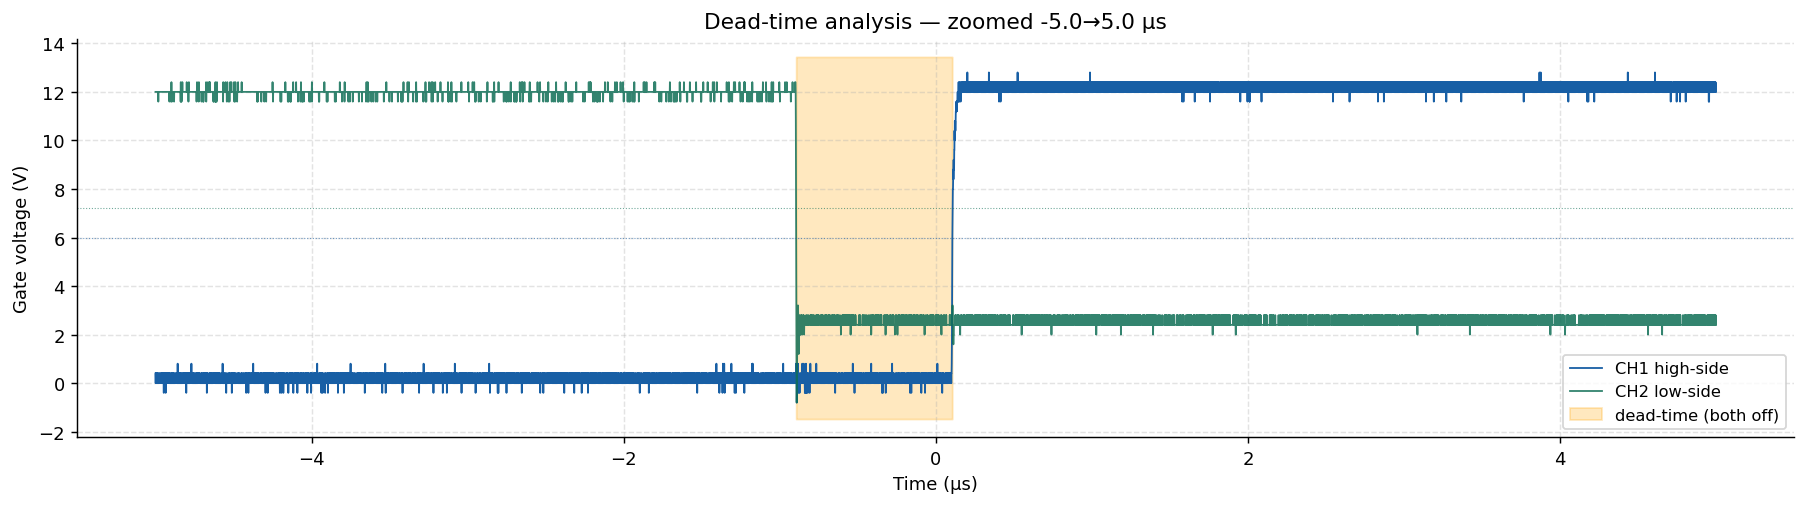

In [6]:
# Thresholds: midpoint of each channel's swing
thr1 = (v1.min() + v1.max()) / 2
thr2 = (v2.min() + v2.max()) / 2

on1 = v1 >= thr1
on2 = v2 >= thr2

both_on   = on1 & on2          # shoot-through
both_off  = (~on1) & (~on2)    # dead-time
only1     = on1 & (~on2)
only2     = (~on1) & on2

dt = INC_S * 1e9   # ns per sample
total_ns = len(time_us) * dt

print(f'Thresholds  — CH1: {thr1:.3f} V   CH2: {thr2:.3f} V')
print(f'Total capture      : {total_ns/1e3:.1f} µs')
print(f'CH1 on only        : {only1.sum()*dt/1e3:.2f} µs  ({100*only1.mean():.1f}%)')
print(f'CH2 on only        : {only2.sum()*dt/1e3:.2f} µs  ({100*only2.mean():.1f}%)')
print(f'Both off (dead-time): {both_off.sum()*dt:.1f} ns  ({100*both_off.mean():.2f}%)')
print(f'SHOOT-THROUGH       : {both_on.sum()*dt:.1f} ns  ({100*both_on.mean():.4f}%)  <-- should be ~0')

# Visual — shade dead-time and overlap on zoom window
mask = (time_us >= T_START) & (time_us <= T_END)
tw = time_us[mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(tw, v1[mask], lw=1.0, color=C1, label='CH1 high-side')
ax.plot(tw, v2[mask], lw=1.0, color=C2, label='CH2 low-side', alpha=0.85)

# Shade dead-time (both off)
dt_win = both_off[mask]
ax.fill_between(tw, ax.get_ylim()[0] if ax.get_ylim()[0] else -1, 
                v1[mask].max()*1.05, where=dt_win,
                color='orange', alpha=0.25, label='dead-time (both off)')

# Shade shoot-through (both on) — should be absent
st_win = both_on[mask]
if st_win.any():
    ax.fill_between(tw, 0, v1[mask].max()*1.05, where=st_win,
                    color='red', alpha=0.5, label='SHOOT-THROUGH')

ax.axhline(thr1, color=C1, lw=0.6, ls=':', alpha=0.6)
ax.axhline(thr2, color=C2, lw=0.6, ls=':', alpha=0.6)
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Gate voltage (V)')
ax.set_title(f'Dead-time analysis — zoomed {T_START}→{T_END} µs')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Switching frequency & duty cycle

CH1 — high-side FET
  Edges detected  : 7 rising
  Freq (median)   : 52.21 kHz
  Freq (mean±std) : 52.21 ± 0.00 kHz
  Duty cycle      : 44.3%

CH2 — low-side FET
  Edges detected  : 8 rising
  Freq (median)   : 52.21 kHz
  Freq (mean±std) : 52.21 ± 0.00 kHz
  Duty cycle      : 45.0%



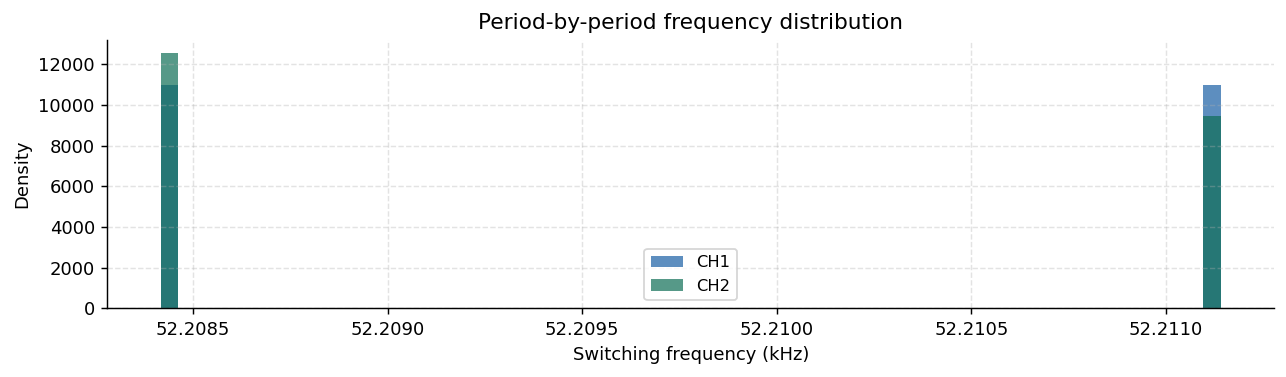

In [7]:
def switching_stats(v, thr, label):
    binary = (v >= thr).astype(int)
    diff   = np.diff(binary)
    rising = np.where(diff == 1)[0]
    if len(rising) < 2:
        print(f'{label}: not enough edges to compute frequency')
        return
    periods_ns = np.diff(rising) * INC_S * 1e9   # ns
    freq_khz   = 1e6 / periods_ns                  # kHz
    duty       = 100 * (v >= thr).mean()
    print(f'{label}')
    print(f'  Edges detected  : {len(rising):,} rising')
    print(f'  Freq (median)   : {np.median(freq_khz):.2f} kHz')
    print(f'  Freq (mean±std) : {freq_khz.mean():.2f} ± {freq_khz.std():.2f} kHz')
    print(f'  Duty cycle      : {duty:.1f}%')
    print()
    return freq_khz

f1 = switching_stats(v1, thr1, 'CH1 — high-side FET')
f2 = switching_stats(v2, thr2, 'CH2 — low-side FET')

if f1 is not None and f2 is not None:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(f1, bins=60, alpha=0.7, color=C1, label='CH1', density=True)
    ax.hist(f2, bins=60, alpha=0.7, color=C2, label='CH2', density=True)
    ax.set_xlabel('Switching frequency (kHz)')
    ax.set_ylabel('Density')
    ax.set_title('Period-by-period frequency distribution')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 8. Power spectral density — both channels

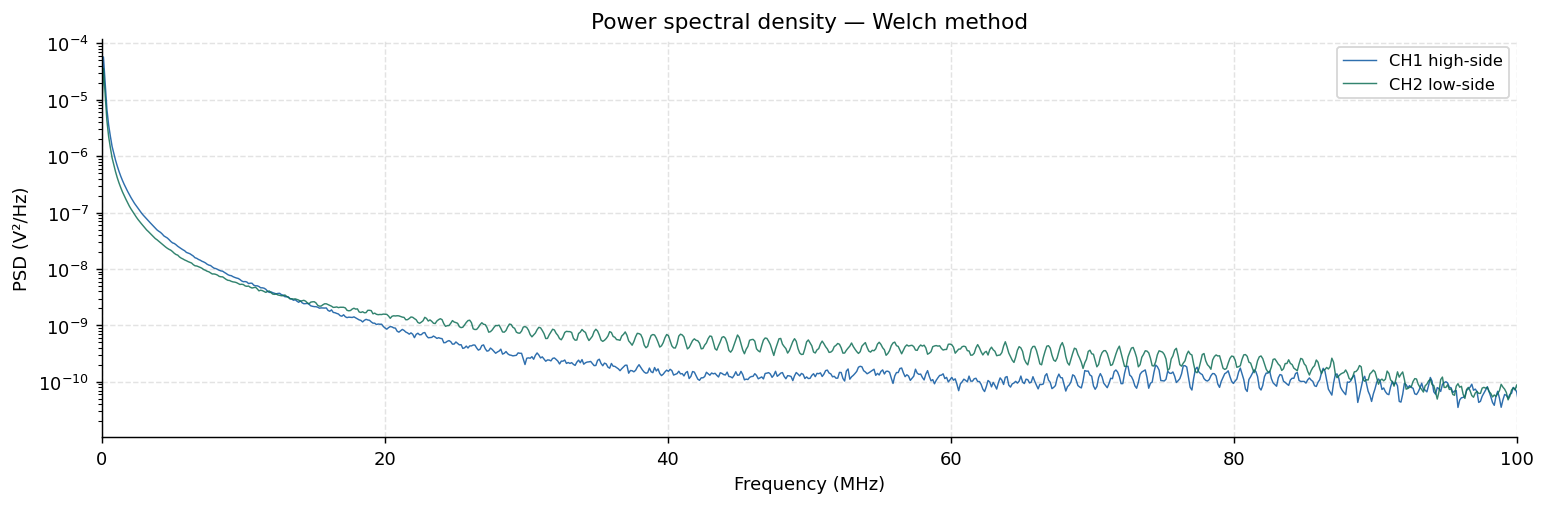

In [8]:
fs = 1 / INC_S   # 1 GHz
f1p, psd1 = signal.welch(v1, fs=fs, nperseg=8192)
f2p, psd2 = signal.welch(v2, fs=fs, nperseg=8192)
fmhz1 = f1p / 1e6
fmhz2 = f2p / 1e6

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(fmhz1, psd1, lw=0.8, color=C1, label='CH1 high-side', alpha=0.9)
ax.semilogy(fmhz2, psd2, lw=0.8, color=C2, label='CH2 low-side',  alpha=0.85)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power spectral density — Welch method')
ax.set_xlim(0, 100)   # focus on sub-100 MHz; extend if needed
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Export summary figure

Saved FET_dual_channel_summary.png


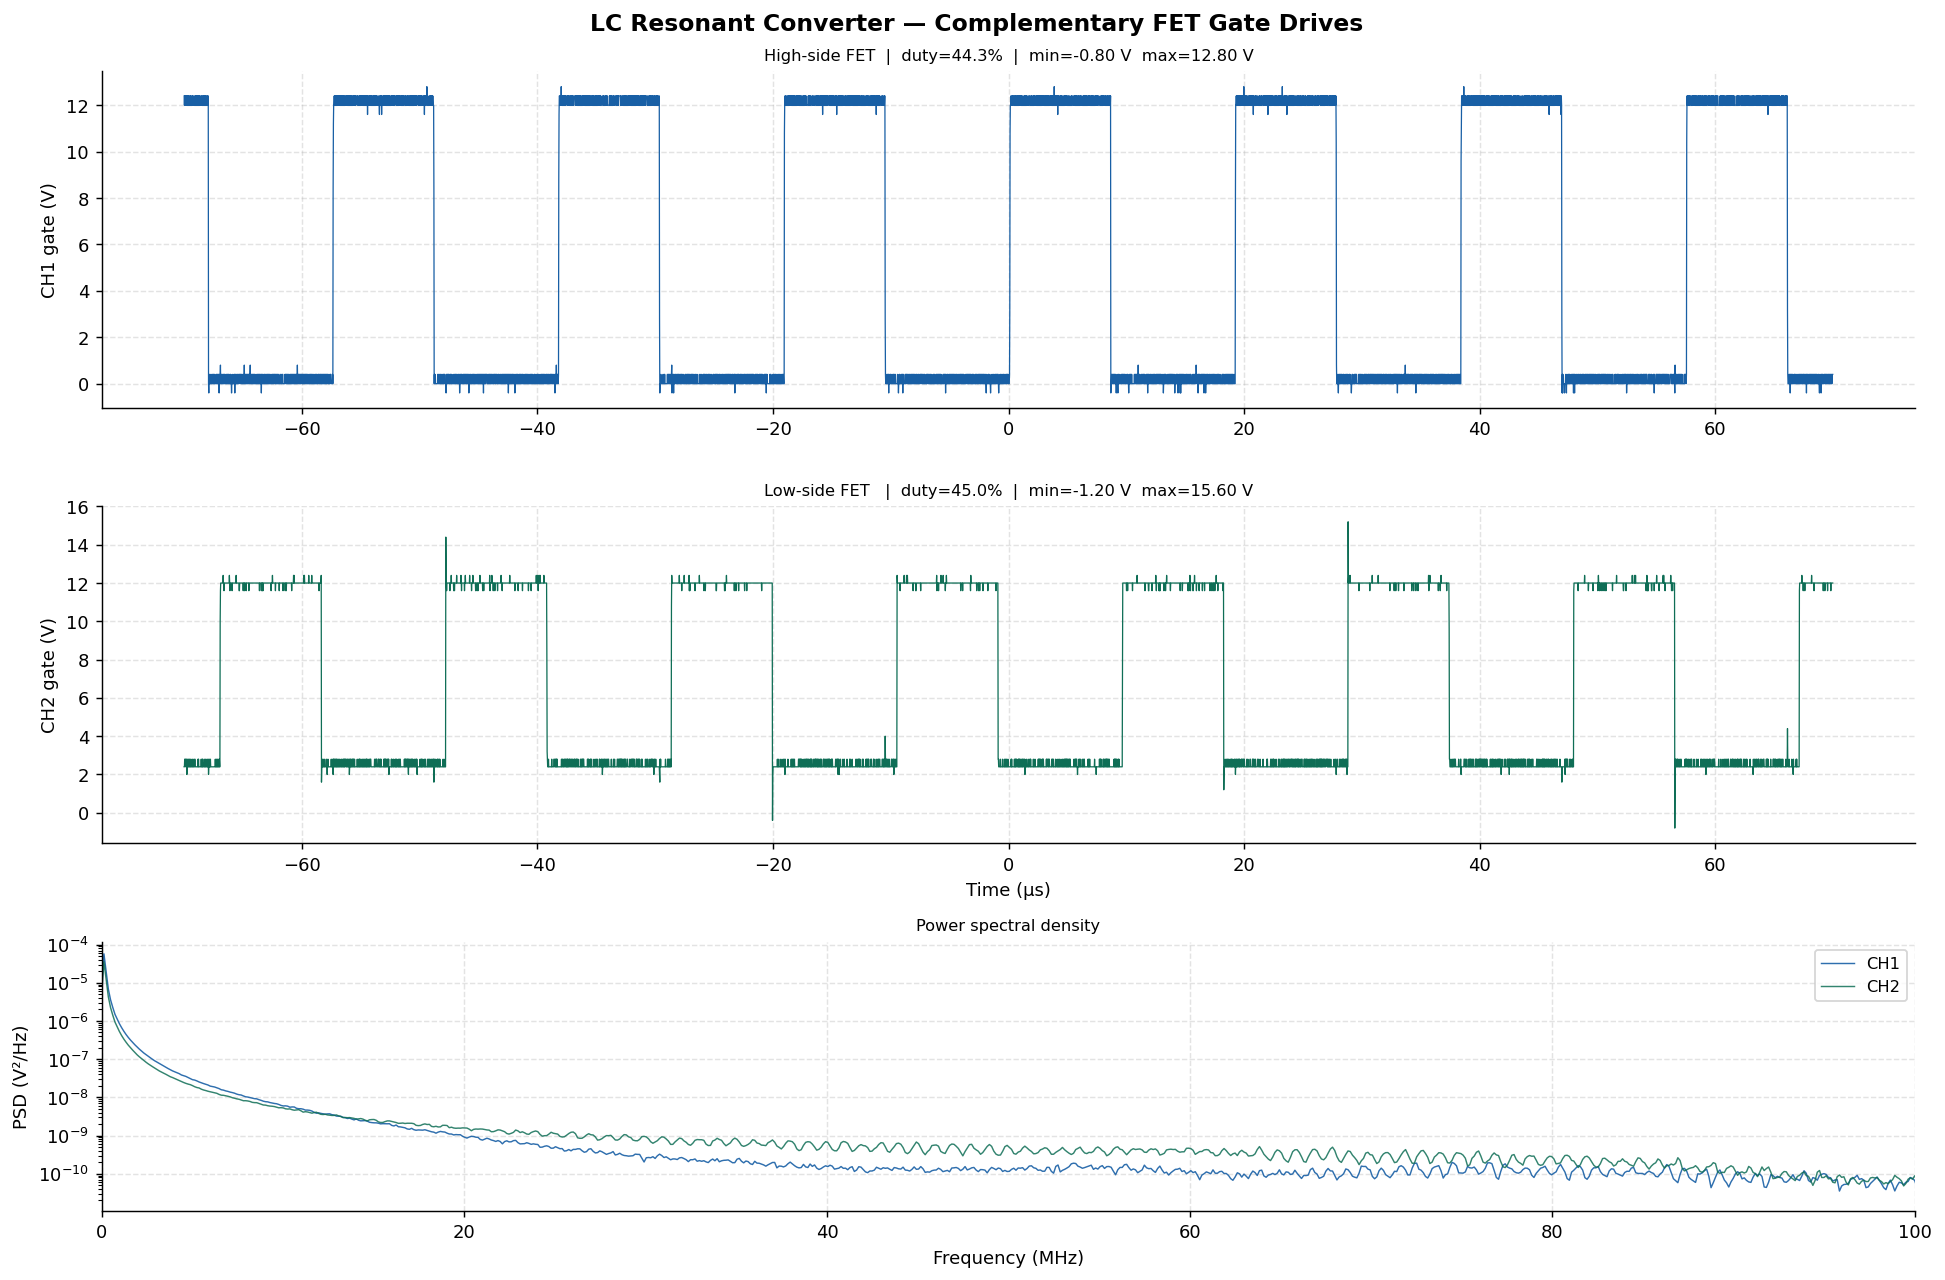

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10),
                          gridspec_kw={'height_ratios': [2.5, 2.5, 2]},
                          sharex=False)
fig.suptitle('LC Resonant Converter — Complementary FET Gate Drives', fontsize=13, fontweight='bold')

# Panel 1: CH1
axes[0].plot(tp, v1[::N], lw=0.7, color=C1, rasterized=True)
axes[0].set_ylabel('CH1 gate (V)')
axes[0].set_title(f'High-side FET  |  duty={100*(v1>=thr1).mean():.1f}%  |  min={v1.min():.2f} V  max={v1.max():.2f} V', fontsize=9)

# Panel 2: CH2
axes[1].plot(tp, v2[::N], lw=0.7, color=C2, rasterized=True)
axes[1].set_ylabel('CH2 gate (V)')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title(f'Low-side FET   |  duty={100*(v2>=thr2).mean():.1f}%  |  min={v2.min():.2f} V  max={v2.max():.2f} V', fontsize=9)

# Panel 3: PSD
axes[2].semilogy(fmhz1, psd1, lw=0.8, color=C1, label='CH1', alpha=0.9)
axes[2].semilogy(fmhz2, psd2, lw=0.8, color=C2, label='CH2', alpha=0.85)
axes[2].set_xlim(0, 100)
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('PSD (V²/Hz)')
axes[2].set_title('Power spectral density', fontsize=9)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('FET_dual_channel_summary.png', dpi=150, bbox_inches='tight')
print('Saved FET_dual_channel_summary.png')
plt.show()